In [1]:
import colorsys
import numpy as np
import matplotlib
import matplotlib.pylab as plt
import scipy
import seaborn as sns
import time

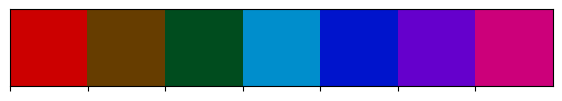

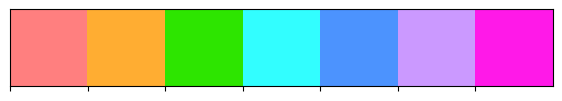

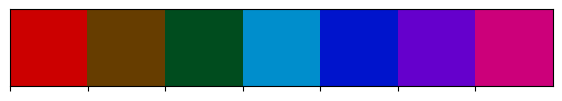

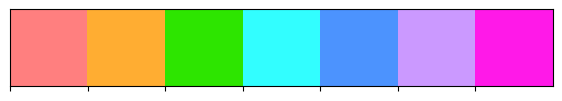

In [2]:
import os
import sys
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import plot_policy_reward, set_blind_colors, plot_env, plot_visit_table_counts, plot_visit_table_heatmap
COLORS, _ = set_blind_colors()

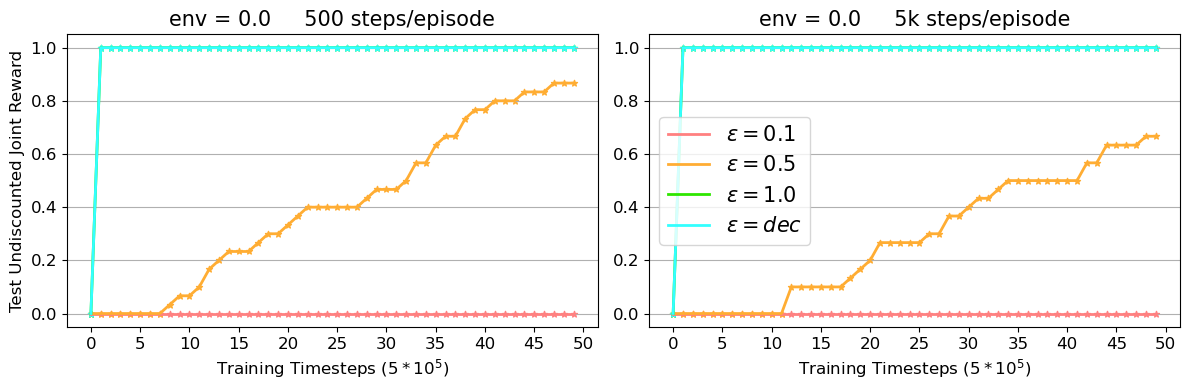

In [5]:
n_seeds = 30
env_random = 0.0
q_lr = 0.1
r_lr = 0.1

fig = plt.figure(figsize=(12, 4))
x_axis = np.arange(50)

for k, n_steps in enumerate([500, "5k"]):
    plt.subplot(1, 2, k + 1)
    epss = [0.1, 0.5, 1.0, "dec"]
    for i, epsilon in enumerate(epss):
        log_dir = "../models_{}/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(n_steps, env_random, epsilon, q_lr, r_lr)
        mean, std = np.zeros((n_seeds, 50)), np.zeros((n_seeds, 50))
        for seed in range(n_seeds):
            test_reward = np.load(log_dir + "/evaluation_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
            for count, key in enumerate(test_reward.keys()):
                mean[seed, count], std[seed, count] = np.mean(test_reward[key]), np.std(test_reward[key])
        plt.plot(x_axis, np.mean(mean, 0), lw=2, c=COLORS[i], alpha=1, label=r"$\epsilon = {}$".format(epsilon))
        plt.scatter(x_axis, np.mean(mean, 0), marker="*", s=20, color=COLORS[i], alpha=1)
        # plt.errorbar(x_axis, np.mean(mean, 0), yerr=np.mean(std, 0), elinewidth=1, capsize=2, c=COLORS[i], alpha=1)
        # plt.errorbar(x_axis, np.mean(mean, 0), yerr=np.std(np.mean(mean, 0)), elinewidth=1, capsize=2, c=COLORS[i], alpha=1)
    plt.title("env = {}     {} steps/episode".format(env_random, n_steps), fontsize=15)
    plt.xlabel(r"Training Timesteps ($5*10^5$)", fontsize=12)
    if k == 0:
        plt.ylabel("Test Undiscounted Joint Reward", fontsize=12)
        plt.yticks(fontsize=12)
    else:
        plt.legend(fontsize=15)
        plt.yticks(fontsize=12)
    plt.grid(axis="y")
    plt.xticks(np.arange(0, 51, 5), fontsize=12)
    # plt.ylim(-5, 1.05)
fig.tight_layout()
# fig.savefig("../test_joint_reward_during_training_env_{}.pdf".format(env_random), dpi=300)

In [161]:
n_steps = "5k"
env_random = 0.0
epsilon= 0.7
q_lr = 1.0
r_lr = 1.0
seed = 1
log_dir = "../models_{}/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(n_steps, env_random, epsilon, q_lr, r_lr)
test_reward = np.load(log_dir + "/evaluation_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]

In [162]:
test_reward

{1: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 21: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 41: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 196: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 1487: array([0.79361428, 0.79361428, 0.79361428, 0.79361428, 0.79361428,
      

## different $\epsilon$ same $Q_{\alpha}$ and $R_{\alpha}$

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


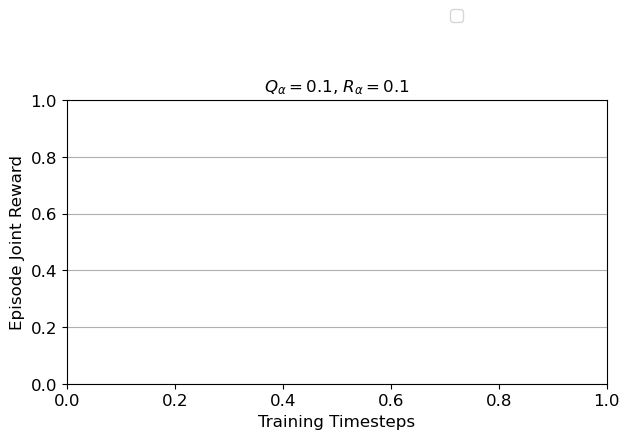

In [6]:
# n_seed = 30
# env_random = 0.1
# q_lr = 0.1
# r_lr = 0.1
# fig = plt.figure(figsize=(7, 4))

# for count, eps in enumerate(["1.0_25m","dec"]):
#     rewards = []
#     for seed in range(n_seed):
#         rewards.append(
#             np.load("../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}/training_joint_reward_{}.npy".format(env_random, eps, q_lr, r_lr, seed), allow_pickle=True,)[()]
#         )
#     fig = plot_policy_reward(fig, rewards, label=r"$\epsilon=$" + str(eps), color=COLORS[count], alpha=1, lw=2, marker=None, linestyle=None)

plt.xlabel("Training Timesteps", fontsize=12)
plt.ylabel("Episode Joint Reward", fontsize=12)
plt.ticklabel_format(axis="x", style="sci", scilimits=(1, 4))
plt.grid(axis="y")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(2e5, 2.41e5)
plt.ylim(-15, -0.5)
legend = plt.legend(fontsize=12, ncol=4, bbox_to_anchor=(0.75, 1.35), fancybox=True)
# fig_legend = legend.figure
# fig_legend.canvas.draw()
# bbox = legend.get_window_extent().transformed(fig_legend.dpi_scale_trans.inverted())
# fig_legend.savefig("../models/9_9/Penalty/reward_model/legend_different_eps.pdf", dpi=300, bbox_inches=bbox)
plt.title(r"$Q_\alpha = {}$, $R_\alpha = {}$".format(q_lr, r_lr))
plt.tight_layout()
# fig.savefig("../models/9_9/Penalty/reward_model/env_{}/q_lr_{}_r_lr_{}_training_reward_eps_zoom.pdf".format(env_random, q_lr, r_lr), dpi=300)

# Plot visit table

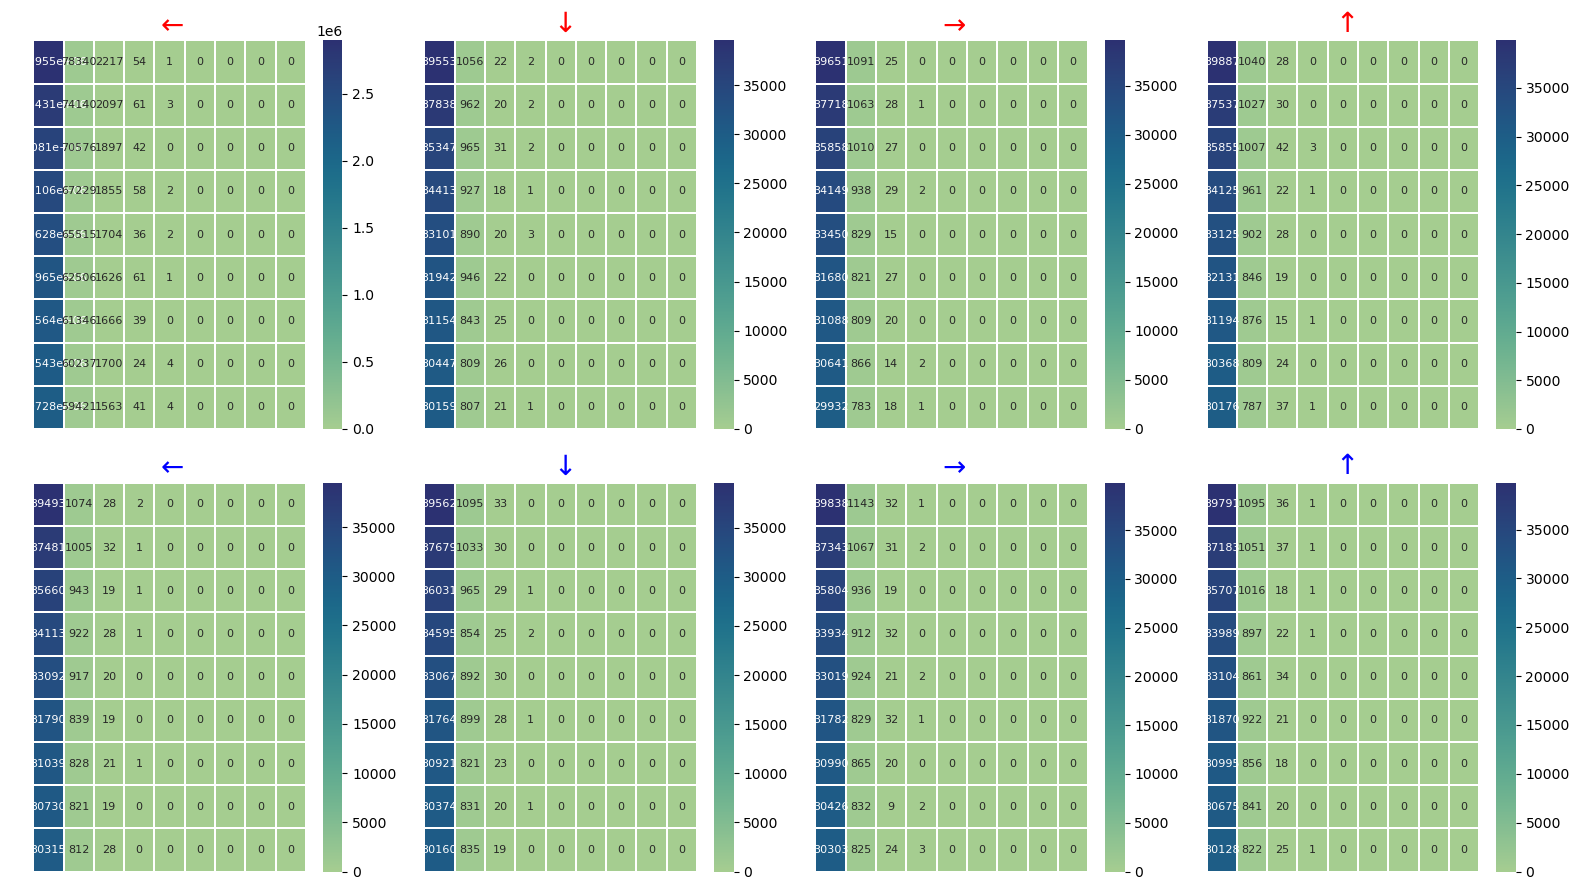

In [7]:
plot_visit_table_heatmap(log_dir, seed=seed, save_fig=False)

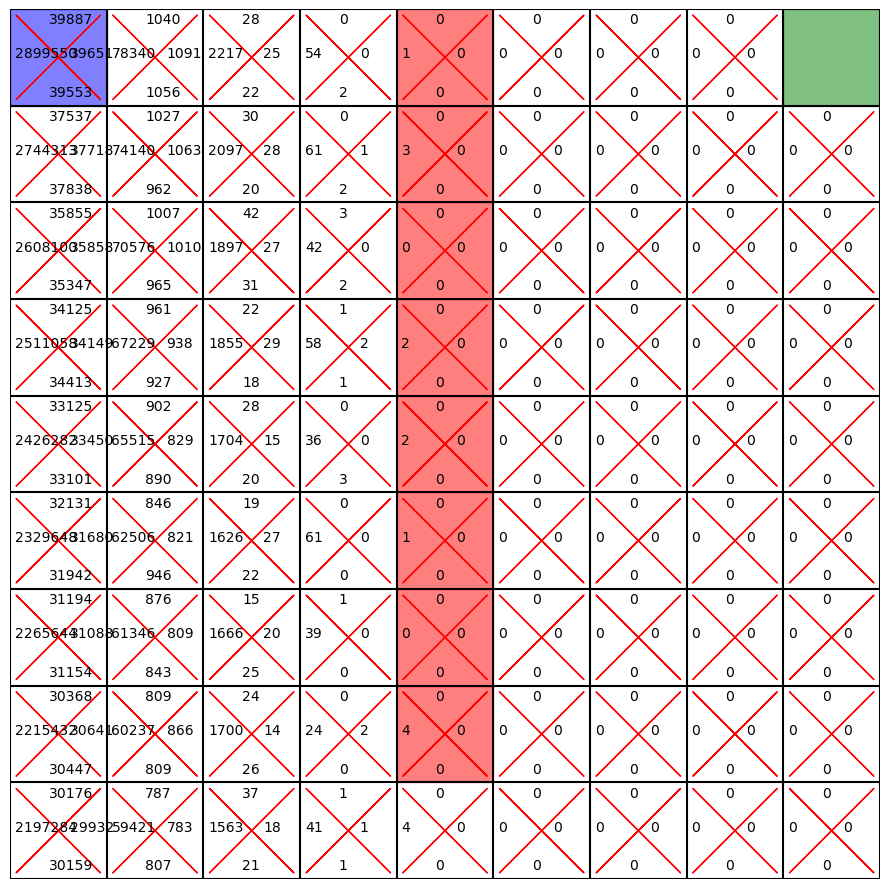

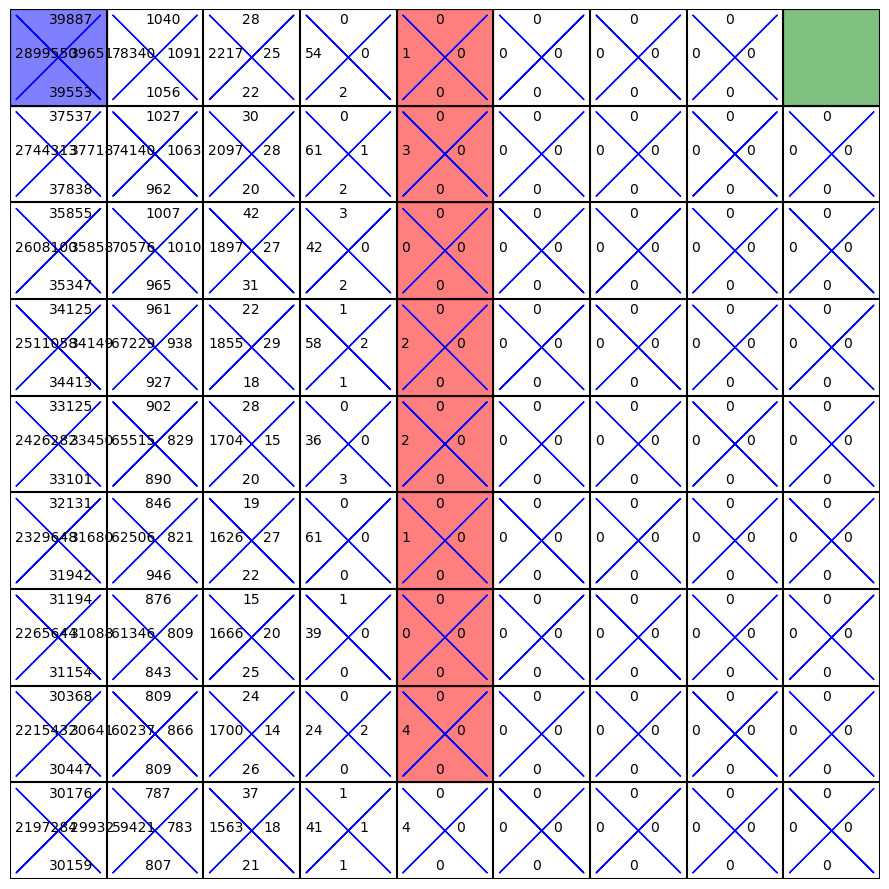

In [8]:
plot_visit_table_counts(log_dir, seed=seed, save_fig=False)

In [387]:
reward_model = np.load(log_dir + "/checkpoints_9/reward_model_table_1.npy")

In [388]:
perfect_r_model = np.load("../models/9_9/Penalty/reward_model/perfect_reward_table.npy")
print(np.nonzero(perfect_r_model - reward_model)[0])

[]


In [381]:
perfect_r_model[4] , reward_model[4]

(array([  0., -10.,   0., -10.]), array([  0., -10.,   0., -10.]))

In [347]:
perfect_r_model[3] - reward_model[3]

array([ 0.28037778,  0.15731661, -0.39255697,  0.21451562])

In [348]:
np.sum(np.load(log_dir + "/visit_table_1.npy"))

1000070.0

In [389]:
int(np.sqrt(81))

9